In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [36]:
print(sklearn.__version__)
print(pd.__version__)

1.8.0
3.0.2


In [37]:
df = pd.read_csv("TravelInsurancePrediction.csv",index_col=0)
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


In [38]:
df.size

17883

In [39]:
df.isnull().sum()

Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

In [40]:
df["AnnualIncome"].max()


np.int64(1800000)

In [41]:
df["Employment Type"].unique()
df["GraduateOrNot"].unique()
df["ChronicDiseases"].unique()

array([1, 0])

(array([813., 806., 145.]),
 array([ 500000., 1000000., 1500000., 1800000.]),
 <BarContainer object of 3 artists>)

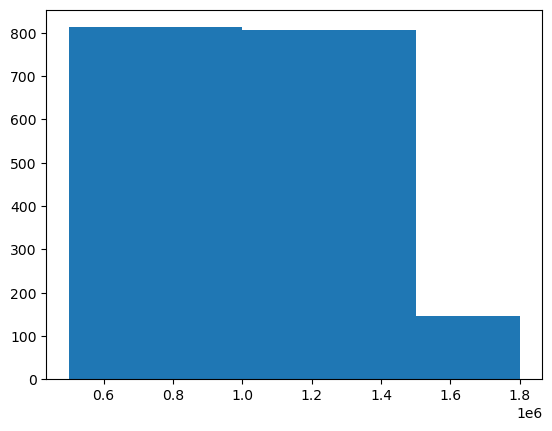

In [42]:
plt.hist(df["AnnualIncome"],bins=[500000,1000000,1500000,1800000])

In [43]:
def salary_aggregate(data):
    if data<500000:
        return "low"
    if data<1000000:
        return "medium"
    if data<1500000:
        return "high"
    else:
        return "very high"

In [44]:
df["Income"] = df["AnnualIncome"].apply(salary_aggregate)
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,Income
0,31,Government Sector,Yes,400000,6,1,No,No,0,low
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,high
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,medium
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0,medium
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0,medium


<Axes: xlabel='FamilyMembers', ylabel='count'>

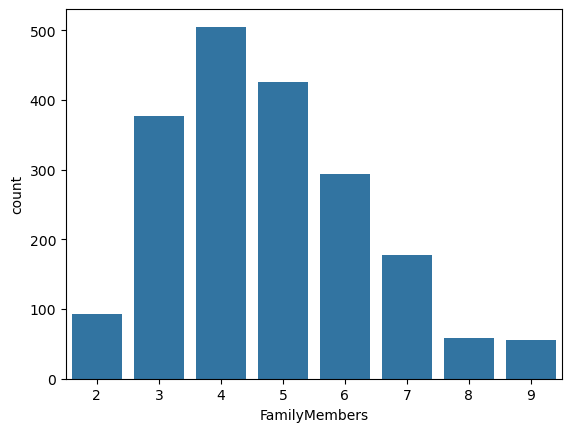

In [45]:
sns.countplot(x="FamilyMembers",data=df)

In [46]:
def family_aggregate(data):
    if data<3:
        return "small"
    if data<6:
        return "medium"
    else:
        return "big"

In [47]:
df["Family"] = df["FamilyMembers"].apply(family_aggregate)
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,Income,Family
0,31,Government Sector,Yes,400000,6,1,No,No,0,low,big
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,high,big
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,medium,medium
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0,medium,medium
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0,medium,big


In [48]:
def yes_no_converter(data):
    if data == 1:
        return "Yes"
    else:
        return "No"
df["ChronicDiseases"] = df["ChronicDiseases"].apply(yes_no_converter)

In [49]:
df.columns

Index(['Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome',
       'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'TravelInsurance', 'Income', 'Family'],
      dtype='str')

In [50]:
df_new = df[['Age', 'Employment Type', 'GraduateOrNot',
    'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'TravelInsurance', 'Income', 'Family']]
df_new.head()

,Age,Employment Type,GraduateOrNot,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,Income,Family
0,31,Government Sector,Yes,Yes,No,No,0,low,big
1,31,Private Sector/Self Employed,Yes,No,No,No,0,high,big
2,34,Private Sector/Self Employed,Yes,Yes,No,No,1,medium,medium
3,28,Private Sector/Self Employed,Yes,Yes,No,No,0,medium,medium
4,28,Private Sector/Self Employed,Yes,Yes,Yes,No,0,medium,big


In [51]:
X = df[['Age', 'Employment Type', 'GraduateOrNot',
        'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'Income', 'Family']]
y=df["TravelInsurance"]

In [52]:
X.columns = X.columns.str.lower().str.replace(" ","_")

In [53]:
X.columns

Index(['age', 'employment_type', 'graduateornot', 'chronicdiseases',
       'frequentflyer', 'evertravelledabroad', 'income', 'family'],
      dtype='str')

In [54]:
num_col = X.select_dtypes(
    exclude=['object']
).columns

cat_col = X.select_dtypes(
    include=['object']
).columns

C:\Users\GAURANG SANE\AppData\Local\Temp\ipykernel_24372\1098375877.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = X.select_dtypes(


In [55]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler())
]
)

cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy="most_frequent")),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

In [56]:
preprocessor = ColumnTransformer([
    ('num',num_pipeline,num_col),
    ('cat',cat_pipeline,cat_col)
])

In [57]:
X

,age,employment_type,graduateornot,chronicdiseases,frequentflyer,evertravelledabroad,income,family
0,31,Government Sector,Yes,Yes,No,No,low,big
1,31,Private Sector/Self Employed,Yes,No,No,No,high,big
2,34,Private Sector/Self Employed,Yes,Yes,No,No,medium,medium
3,28,Private Sector/Self Employed,Yes,Yes,No,No,medium,medium
4,28,Private Sector/Self Employed,Yes,Yes,Yes,No,medium,big
...,...,...,...,...,...,...,...,...
1982,33,Private Sector/Self Employed,Yes,No,Yes,Yes,very high,medium
1983,28,Private Sector/Self Employed,Yes,Yes,No,Yes,very high,medium
1984,28,Private Sector/Self Employed,Yes,Yes,No,No,high,big
1985,34,Private Sector/Self Employed,Yes,No,Yes,Yes,high,big


In [58]:
y

0       0
1       0
2       1
3       0
4       0
       ..
1982    1
1983    0
1984    0
1985    1
1986    0
Name: TravelInsurance, Length: 1987, dtype: int64

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [60]:
model_name = {
    "LogisticRegression":LogisticRegression(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "RandomForestClassifier":RandomForestClassifier(),
    "SVC":SVC(),
    "KNN":KNeighborsClassifier()
}

In [61]:
from sklearn.model_selection import cross_val_score
results = []
for name,model in model_name.items():
    pipeline = Pipeline([
        ('preprocessing',preprocessor),
        ('model',model)
    ])

    scores = cross_val_score(
             pipeline,
             X_train,
             y_train,
             cv=5
    )

    results.append(f"{name}:{scores.mean()}")

In [62]:
results

['LogisticRegression:0.7734380890026388',
 'DecisionTreeClassifier:0.7992480606313117',
 'RandomForestClassifier:0.8055433208340774',
 'SVC:0.8131004106898401',
 'KNN:0.7923456937087078']

In [63]:
final_pipeline = Pipeline([
    ("preprocessing",preprocessor),
    ("model",SVC())
])

In [64]:
final_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [65]:
y_pred =final_pipeline.predict(X_test)

In [66]:
accuracy = accuracy_score(y_pred,y_test)
accuracy

0.821608040201005

In [67]:
import joblib
joblib.dump(final_pipeline,"Travel_Insurance_Model.pkl")

['Travel_Insurance_Model.pkl']